<div align="center">

# **PROYECTO FINAL**
## **Dataset de Películas**

### Minería de Datos  



**Fuente:** Hugging Face – TMDB Movies Dataset



**Integrantes**  
Juan Daniel Ramirez Mojica

Maria Paula Carvajal Martinez


Paula Daniela Guzman Zabala

Karem Nataly Sierra Molina




**Universidad**  
Universidad Nacional de Colombia


**Semestre**  
2026-1

</div>


---
## **1. Descripción del Dataset**

### **1.1. Fuente y Contexto**

**Fuente del Dataset:**

> [1] Datadruids, *"Full TMDB Movies Dataset"*, HuggingFace.co, 2026. Disponible en: https://huggingface.co/datasets/ada-datadruids/full_tmdb_movies_dataset. [Acceso: 24 feb. 2026]

El dataset proviene de **TMDB (The Movie Database)**, una base de datos cinematográfica colaborativa con información de millones de producciones a nivel mundial.

### **1.2. ¿Qué contiene el dataset?**

El dataset contiene **1,142,342 registros** de películas y **24 variables** que describen características como título, géneros, popularidad, presupuesto, recaudación, sinopsis y palabras clave. Incluye tanto variables numéricas (`vote_count`, `revenue`, `runtime`, `popularity`) como variables textuales (`overview`, `genres`, `keywords`), lo que permite combinar análisis estadístico con procesamiento de lenguaje natural (NLP).

| Tipo | Variables | Cantidad |
|------|-----------|----------|
| `int64` | id, vote_count, revenue, runtime, budget | 5 |
| `float64` | vote_average, popularity | 2 |
| `bool` | adult | 1 |
| `object` (texto) | title, overview, genres, keywords, status, ... | 16 |

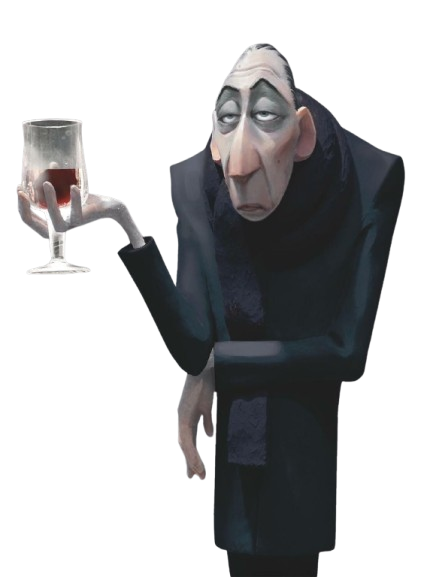

### **1.2. Objetivo del Análisis**
El objetivo es construir un **sistema de recomendación de películas basado en contenido** que funcione sin historial previo del usuario (*cold-start*).

El sistema opera en dos etapas:

1. **Filtrado inicial** por género y calificación mínima para reducir el catálogo a opciones relevantes.
2. **Recomendación por similitud**: dado un título seleccionado, el modelo calcula similitud de contenido usando `TF-IDF` sobre `overview`, `genres` y `keywords` para sugerir películas similares.

> 📎 **Presentación**: https://www.canva.com/design/DAHCP12ebtc/5khUpBy5Q0LfSIDzacsflA/edit

---
## **2. Configuración y Carga de Datos**

### **2.1. Instalación e Importaciones**
Ejecutar solo la primera vez:

In [52]:
pip install datasets


Note: you may need to restart the kernel to use updated packages.


In [53]:
from datasets import load_dataset
import pandas as pd

### **2.2. Carga del Dataset**

El dataset se descarga desde Hugging Face. La librería `datasets` cachea automáticamente la descarga, por lo que la segunda ejecución es instantánea.

In [54]:

# Cargar el dataset desde Hugging Face
dataset = load_dataset("ada-datadruids/full_tmdb_movies_dataset")

# Ver splits disponibles
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords'],
        num_rows: 1142342
    })
})


In [55]:
# Convertir el split "train" a pandas
df = dataset["train"].to_pandas()

# Convertir a DataFrame de pandas
df = dataset['train'].to_pandas()

print(f'Dataset cargado: {len(df):,} filas × {df.shape[1]} columnas')


Dataset cargado: 1,142,342 filas × 24 columnas


### **2.3. Inspección Inicial**

A continuación veremos archivos descargados, junto a la creación de la ruta correcta, y la carga de datos:

In [56]:
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [57]:
df.tail()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
1142337,741864,Criadores de Melodias - As Lendas do Rock,0.0,0,Released,None,0,0,False,None,...,Criadores de Melodias - As Lendas do Rock,None,0.600,/lZtb2L6E5e0MGBe3iMBl168A8fG.jpg,None,None,None,None,None,None
1142338,741865,Aprenda Trombone Gospel Básico,0.0,0,Released,None,0,0,False,None,...,Aprenda Trombone Gospel Básico,None,0.600,None,None,None,None,None,None,None
1142339,741866,Aprenda Violão Avançado,0.0,0,Released,None,0,0,False,None,...,Aprenda Violão Avançado,None,0.600,/itp1p8Ex8gdSiCcdHfgKcZbhAWw.jpg,None,None,None,None,None,None
1142340,72865,Our Big Sister,0.0,0,Released,1964-04-22,0,0,False,None,...,Our Big Sister,None,0.841,None,None,Drama,None,Hong Kong,Cantonese,None
1142341,1397642,I WANT MY MOMMY,0.0,0,Released,2025-01-31,0,19,False,/f1RJgdrusjuOWn4DJtZq1CtCgbh.jpg,...,I WANT MY MOMMY,"Mourning the death of his mother, a man is pre...",0.600,/uiZePWWCYmwSsydMzZe6OEpva1O.jpg,Mommy Loves You... No Matter What,"Drama, Comedy",Four Eyes Films,United States of America,English,None


---
## **3. Análisis Exploratorio de Datos (AED)**

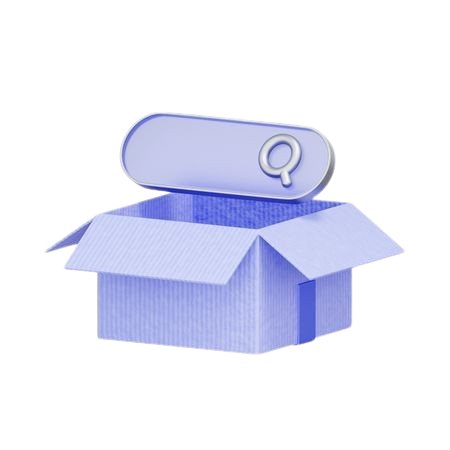

### **3.1. Calidad y Estructura del Dataset**

**Dimensiones:**

In [58]:
filas, columnas = df.shape
print(f'Filas    : {filas:>10,}')
print(f'Columnas : {columnas:>10}')

Filas    :  1,142,342
Columnas :         24


**Tipos de variables:**

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1142342 entries, 0 to 1142341
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1142342 non-null  int64  
 1   title                 1142329 non-null  object 
 2   vote_average          1142342 non-null  float64
 3   vote_count            1142342 non-null  int64  
 4   status                1142342 non-null  object 
 5   release_date          953051 non-null   object 
 6   revenue               1142342 non-null  int64  
 7   runtime               1142342 non-null  int64  
 8   adult                 1142342 non-null  bool   
 9   backdrop_path         302739 non-null   object 
 10  budget                1142342 non-null  int64  
 11  homepage              120868 non-null   object 
 12  imdb_id               604127 non-null   object 
 13  original_language     1142342 non-null  object 
 14  original_title        1142329 non-

Los tipos de datos incluyen **5 enteras**, **2 flotantes**, **1 booleana** y **16 de tipo objeto** (texto). Las columnas de texto requieren preprocesamiento NLP antes del modelado

**Valores nulos por columna:** — ordenados de mayor a menor:

In [60]:
# Conteo y porcentaje de nulos, ordenado descendentemente
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    '% del total': nulos_pct
}).query('Nulos > 0').sort_values('Nulos', ascending=False)

display(resumen_nulos)

,Nulos,% del total
homepage,1021474,89.4
tagline,982211,86.0
backdrop_path,839603,73.5
keywords,833525,73.0
production_companies,627504,54.9
imdb_id,538215,47.1
production_countries,507248,44.4
spoken_languages,487820,42.7
genres,458710,40.2
poster_path,361629,31.7


Las columnas más críticas para el recomendador presentan alta tasa de nulos en el dataset completo:

| Columna | Nulos approx. | % |
|---------|--------------|---|
| `keywords` | ~833K | 73% |
| `homepage` | ~1,017K | 89% |
| `tagline` | ~982K | 86% |
| `genres` | ~459K | 40% |
| `overview` | ~232K | 20% |

#### Patrón de valores nulos

El conteo numérico dice *cuántos* nulos hay, pero no *si tienen un patrón*. Usamos `missingno` para visualizar si los nulos son aleatorios (MCAR) o sistemáticos (MAR/MNAR):

/tmp/ipykernel_14157/1613914687.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


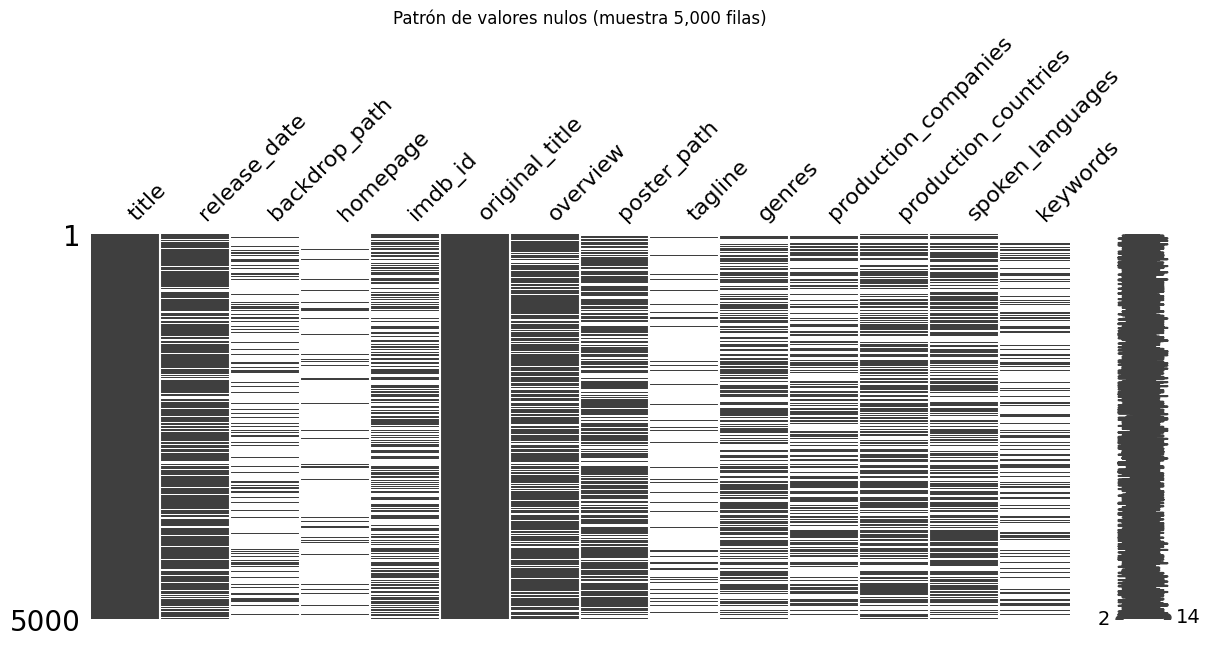

In [61]:
import missingno as msno
import matplotlib.pyplot as plt
# Solo las columnas con al menos un nulo
cols_con_nulos = df.columns[df.isnull().any()].tolist()

msno.matrix(df[cols_con_nulos].sample(5000, random_state=42), figsize=(14, 5))
plt.title('Patrón de valores nulos (muestra 5,000 filas)')
plt.tight_layout()
plt.show()

**¿Cómo leer esta matriz?**

- Líneas **grises** = valor presente &nbsp;|&nbsp; Líneas **blancas** = valor nulo
- Si los blancos se concentran en las mismas filas para varias columnas → patrón **MAR/MNAR** (los registros incompletos lo son en múltiples campos a la vez).
- Esto justifica **eliminar** esas filas en lugar de imputar: si una película no tiene `overview` ni `genres`, tampoco tiene otras variables útiles.

### **3.2. Estadísticas Univariadas**

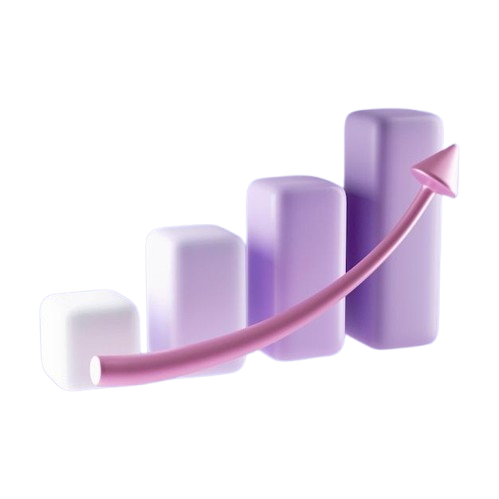

Calculamos las principales medidas de tendencia central y dispersión:


| Medida | Qué mide | Para qué sirve |
|--------|----------|----------------|
| **Media** | Promedio aritmético | Valor típico general |
| **Mediana** | Valor central (50%) | Robusta ante outliers |
| **Desv. Std** | Dispersión respecto a la media | Detectar variabilidad |
| **Min / Max** | Valores extremos | Identificar rango real y anomalías |

In [62]:
df.describe().T  ### .T para leer por variable, no por estadístico


,count,mean,std,min,25%,50%,75%,max
id,1142342.0,743886.594286,3.975214e+05,2.0,412592.25,748970.5,1097094.750,1.397836e+06
vote_average,1142342.0,1.871655,3.017612e+00,0.0,0.00,0.0,4.700,1.000000e+01
vote_count,1142342.0,18.776422,3.177172e+02,0.0,0.00,0.0,1.000,3.449500e+04
revenue,1142342.0,688689.482194,1.790831e+07,-12.0,0.00,0.0,0.000,3.000000e+09
runtime,1142342.0,47.661123,6.165081e+01,-28.0,0.00,22.0,89.000,1.440000e+04
budget,1142342.0,267266.149376,5.062581e+06,0.0,0.00,0.0,0.000,1.000000e+09
popularity,1142342.0,1.231351,7.568423e+00,0.0,0.60,0.6,0.876,2.994357e+03


¿Qué podemos interpretar de estas medidas obtenidas?

#### Interpretación del resumen estadístico

- **`vote_average`**: media 1.87, mediana 0 → más del 50% de las películas no tienen calificación. Las que sí tienen votos se concentran entre 5 y 8.
- **`vote_count`**: media ~19, mediana 0 → la distribución es una *ley de potencia*: pocos blockbusters concentran casi todos los votos.
- **`revenue` / `budget`**: mediana 0 en ambas → los ceros representan *datos ausentes* codificados como 0, no ingresos reales de cero. Esto invalida el uso de estas columnas sin transformación.
- **`runtime`**: media ~51 min pero mediana ~74 min → muchos valores en 0 jalan la media hacia abajo. Hay también outliers de miles de minutos (errores de entrada)

In [63]:

VARS_NUM = ['vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity']

resumen = df[VARS_NUM].agg(['mean', 'median', 'std', 'min', 'max']).T
resumen.columns = ['Media', 'Mediana', 'Desv. Std', 'Mínimo', 'Máximo']

resumen.style.background_gradient(cmap='Blues').format('{:,.2f}')

,Media,Mediana,Desv. Std,Mínimo,Máximo
vote_average,1.87,0.00,3.02,0.00,10.00
vote_count,18.78,0.00,317.72,0.00,"34,495.00"
revenue,"688,689.48",0.00,"17,908,310.80",-12.00,"3,000,000,000.00"
runtime,47.66,22.00,61.65,-28.00,"14,400.00"
budget,"267,266.15",0.00,"5,062,581.18",0.00,"999,999,999.00"
popularity,1.23,0.60,7.57,0.00,"2,994.36"


Se utilizó un mapa de calor (heatmap) para visualizar de forma intuitiva las principales estadísticas descriptivas de las variables numéricas.
La intensidad del color representa la magnitud de cada medida, permitiendo identificar rápidamente diferencias en dispersión, rangos de valores y tendencias generales entre las variables analizadas.

A partir del mapa de calor se observa que variables como revenue, budget, vote_count y popularity presentan una alta dispersión y rangos extremadamente amplios, lo que sugiere distribuciones fuertemente asimétricas hacia la derecha y la presencia de valores atípicos (outliers). Esto se confirma al notar que sus medianas y primeros cuartiles son iguales a cero, mientras que sus medias son considerablemente superiores, indicando que unos pocos valores extremos influyen de manera importante en la tendencia central.

### **3.3. Estadísticas Multivariadas**

Analizamos las relaciones entre pares de variables mediante covarianza y correlación de Pearson:

In [64]:
# Variables numéricas de interés para el análisis multivariado
VARS_NUM = ['vote_average', 
            'vote_count', 
            'revenue', 
            'runtime', 
            'budget', 
            'popularity']

def matriz_covarianza(df, cols):
 
    return df[cols].cov().round(2)

def matriz_correlacion(df, cols, method='pearson'):
    
    return df[cols].corr(method=method).round(2)

covarianza  = matriz_covarianza(df, VARS_NUM)
correlacion = matriz_correlacion(df, VARS_NUM)

print('MATRIZ DE COVARIANZA')
display(covarianza)
print('\nMATRIZ DE CORRELACIÓN (Pearson)')
display(correlacion)

MATRIZ DE COVARIANZA


,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,9.11,9.308000e+01,3.080976e+06,42.59,1.051456e+06,2.72
vote_count,93.08,1.009442e+05,3.949708e+09,1173.62,9.117200e+08,610.95
revenue,3080976.17,3.949708e+09,3.207076e+14,45824727.51,5.807766e+13,30603104.54
runtime,42.59,1.173620e+03,4.582473e+07,3800.82,1.685748e+07,32.83
budget,1051455.68,9.117200e+08,5.807766e+13,16857482.83,2.562973e+13,9145858.30
popularity,2.72,6.109500e+02,3.060310e+07,32.83,9.145858e+06,57.28



MATRIZ DE CORRELACIÓN (Pearson)


,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,1.00,0.10,0.06,0.23,0.07,0.12
vote_count,0.10,1.00,0.69,0.06,0.57,0.25
revenue,0.06,0.69,1.00,0.04,0.64,0.23
runtime,0.23,0.06,0.04,1.00,0.05,0.07
budget,0.07,0.57,0.64,0.05,1.00,0.24
popularity,0.12,0.25,0.23,0.07,0.24,1.00


In [65]:
print("\nMATRIZ DE CORRELACIÓN \n")
correlacion


MATRIZ DE CORRELACIÓN 



,vote_average,vote_count,revenue,runtime,budget,popularity
vote_average,1.00,0.10,0.06,0.23,0.07,0.12
vote_count,0.10,1.00,0.69,0.06,0.57,0.25
revenue,0.06,0.69,1.00,0.04,0.64,0.23
runtime,0.23,0.06,0.04,1.00,0.05,0.07
budget,0.07,0.57,0.64,0.05,1.00,0.24
popularity,0.12,0.25,0.23,0.07,0.24,1.00


**Correlaciones más relevantes:**

- `revenue` ↔ `vote_count` (~0.69): las películas más distribuidas recaudan más *y* reciben más votos.
- `budget` ↔ `revenue` (~0.64): mayor inversión suele asociarse con mayor retorno, aunque con mucha dispersión.
- `vote_average` ↔ todo: correlaciones muy bajas (máx. ~0.23). **La calidad percibida es independiente del éxito comercial.** Una película puede ser muy bien valorada sin ser taquillera.

> 💡 Las correlaciones de Pearson son sensibles a outliers. Con distribuciones tan sesgadas, la correlación de **Spearman** es más robusta: `matriz_correlacion(df, VARS_NUM, method='spearman')`.

#### Heatmap de Correlaciones

Visualización matricial para identificar relaciones de un vistazo:

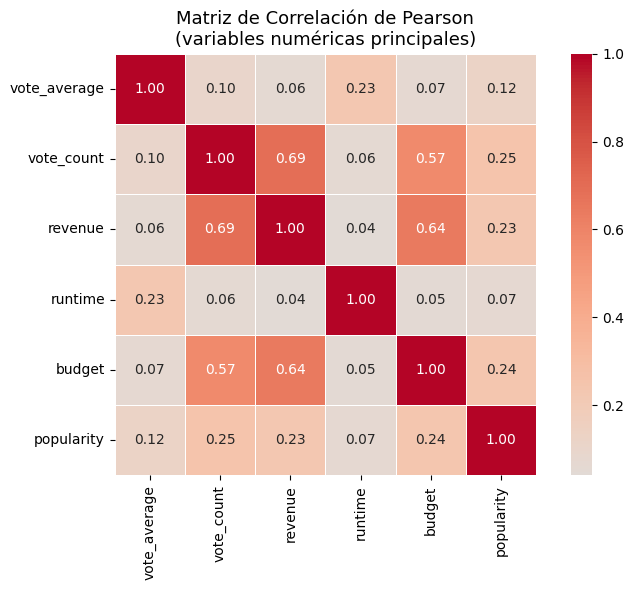

In [66]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matriz de Correlación de Pearson\n(variables numéricas principales)', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación del heatmap:**

-  **Rojo intenso** → correlación positiva fuerte (cercana a +1)
-  **Azul intenso** → correlación negativa fuerte (cercana a -1)
-  **Blanco** → sin correlación

Las correlaciones más relevantes para el objetivo del recomendador:
- `revenue` ↔ `vote_count`: la más fuerte (~0.69) — películas populares recaudan más
- `budget` ↔ `revenue`: inversión alta suele asociarse con mayor recaudación (~0.64)
- `vote_average` → correlaciones débiles con todo: **la calidad percibida es independiente del éxito comercial**

### **3.4. Visualizaciones**

#### **3.4.1. Importaciones para visualización**

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler


#### **3.4.2. Histogramas**

Primero graficamos sin filtrar para mostrar el problema de los ceros masivos:

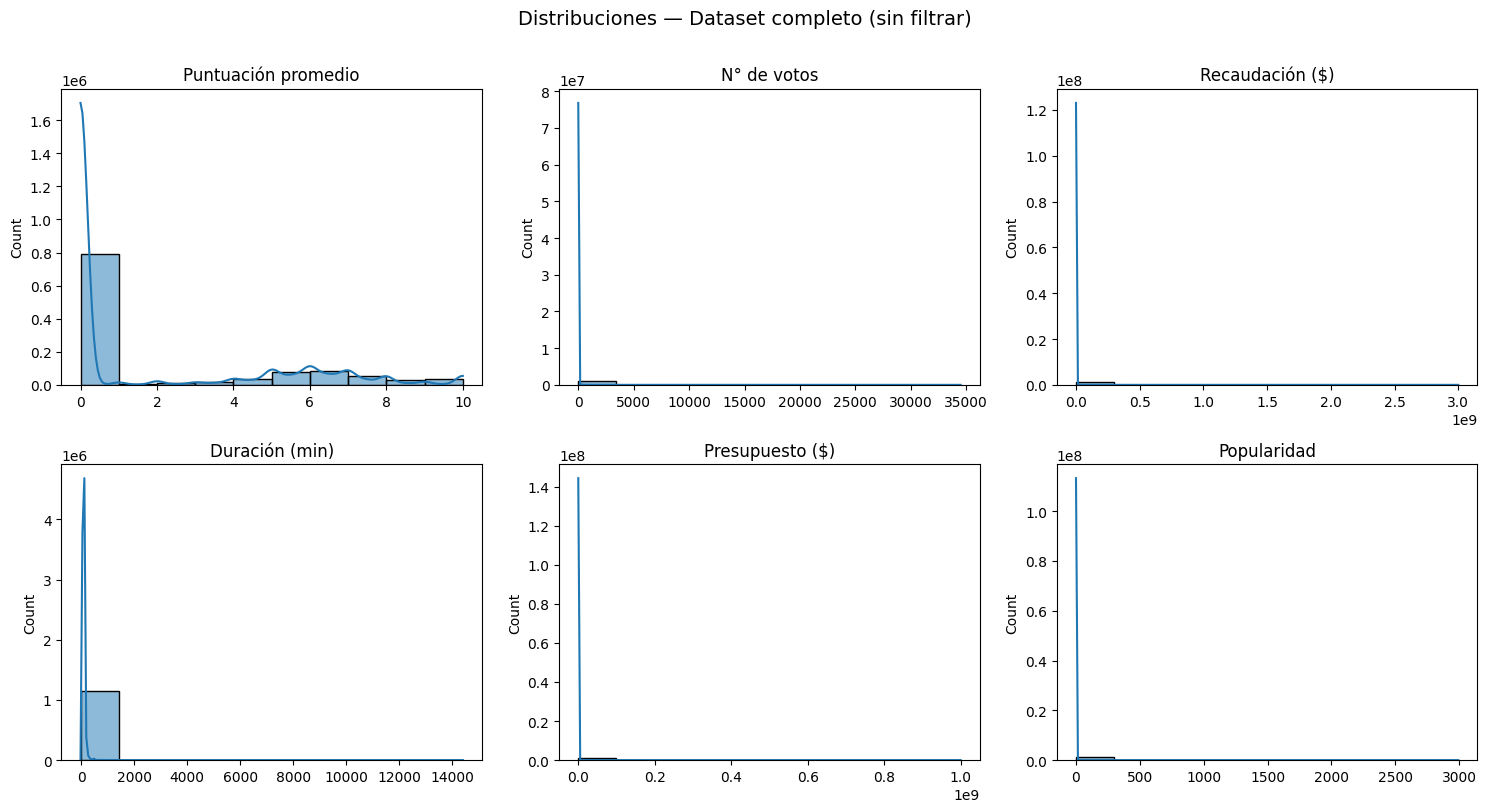

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

VARS_HIST = ['vote_average', 
             'vote_count',
               'revenue',
                 'runtime', 
                 'budget', 
                 'popularity']
LABELS    = ['Puntuación promedio',
              'N° de votos', 
              'Recaudación ($)',
             'Duración (min)', 
             'Presupuesto ($)',
               'Popularidad']

for ax, var, label in zip(axes, VARS_HIST, LABELS):
    sns.histplot(df[var], kde=True, bins=10, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('')

fig.suptitle('Distribuciones — Dataset completo (sin filtrar)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Problema visible:** todas las variables muestran una barra dominante en 0 que aplasta el resto de la distribución. Esto se debe a que la mayoría de películas no tienen datos financieros ni votos registrados. En `runtime` aparecen outliers de hasta 14,400 min (~10 días), claramente errores de entrada. **Necesitamos filtrar antes de analizar.**

Películas con datos completos: 10,362 de 1,142,342 (0.9%)


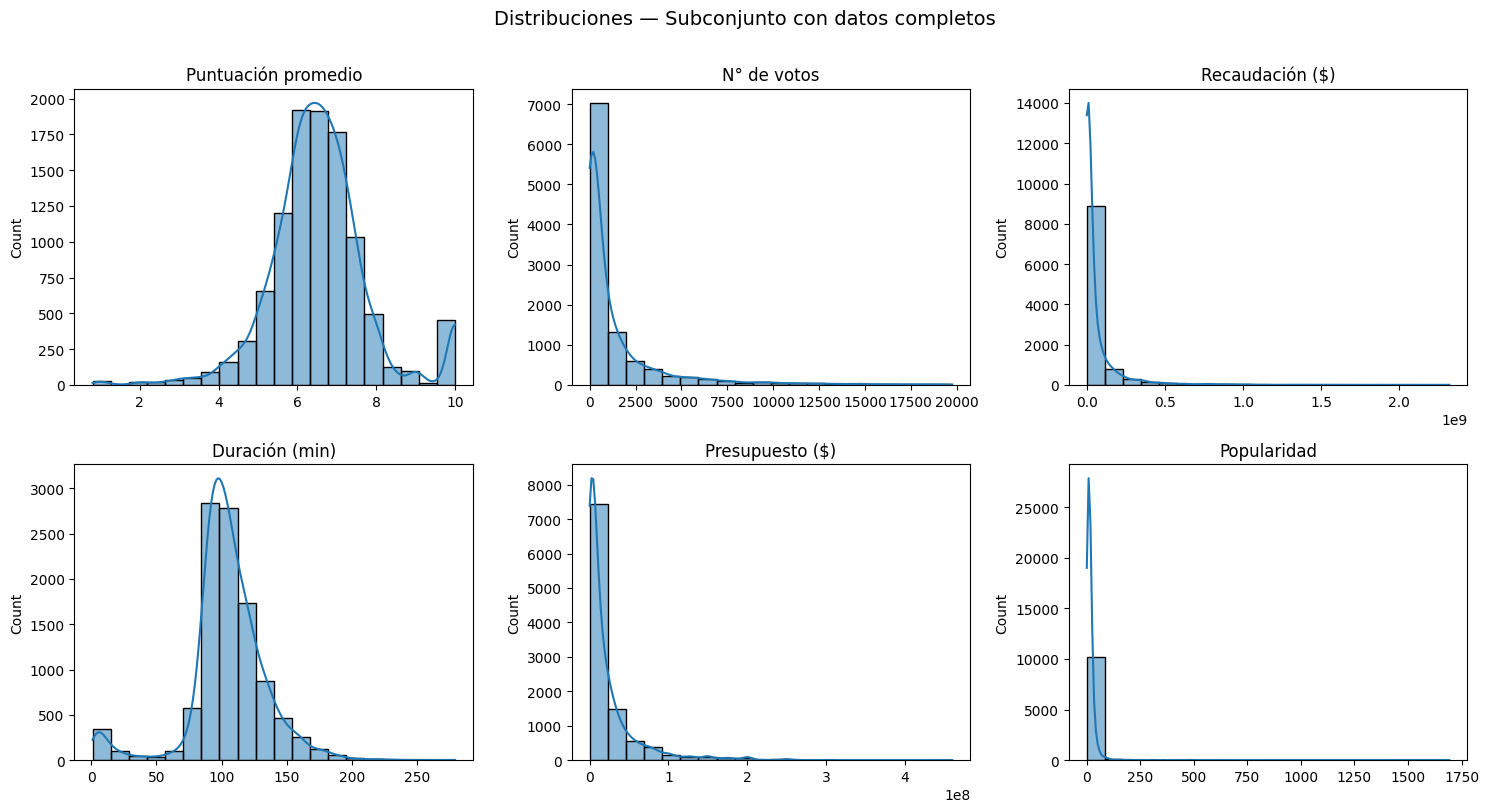

In [69]:

df_viz = df[
    (df['vote_average'] > 0) &
    (df['vote_count'].between(1, 20_000)) &
    (df['revenue'] > 0) &
    (df['runtime'].between(1, 300)) & 
    (df['budget'] > 0) &
    (df['popularity'].between(0.001, 2_000))
].copy()

print(f'Películas con datos completos: {len(df_viz):,} '
      f'de {len(df):,} ({len(df_viz)/len(df)*100:.1f}%)')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, var, label in zip(axes, VARS_HIST, LABELS):
    sns.histplot(df_viz[var], kde=True, bins=20, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('')

fig.suptitle('Distribuciones — Subconjunto con datos completos', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Con datos completos se revela la distribución real:

- **`vote_average`**: aproximadamente normal, concentrada entre 5 y 8.
- **`vote_count`, `popularity`, `revenue`, `budget`**: sesgadas a la derecha (*ley de potencia*) — pocas películas concentran la mayor atención e inversión. Esto es **normal** en consumo cultural, no ruido.
- **`runtime`**: concentrada entre 80 y 120 min, rango típico del largometraje.

A continuación se presentan los histogramas del subconjunto resultante:

- **Puntuación Promedio** — Se espera una distribución concentrada entre 5 y 8, típica de películas con suficientes votos para estabilizar su calificación.
- **Número de Votos** — Distribución fuertemente sesgada a la derecha: la mayoría de películas tiene pocos votos y solo unas pocas superan los miles.
- **Recaudación** — Sesgo extremo a la derecha, con la mayoría de películas recaudando poco y un grupo reducido de blockbusters concentrando los valores más altos.
- **Duración** — Se espera una concentración entre 80 y 120 minutos, rango típico del largometraje comercial.
- **Presupuesto** — Similar a recaudación, con fuerte sesgo a la derecha y pocos títulos con presupuestos muy elevados.
- **Popularidad** — Distribución tipo ley de potencia: la mayoría de películas tiene popularidad baja y solo unos pocos títulos concentran valores muy altos.

#### **3.4.3. Variables Categóricas**

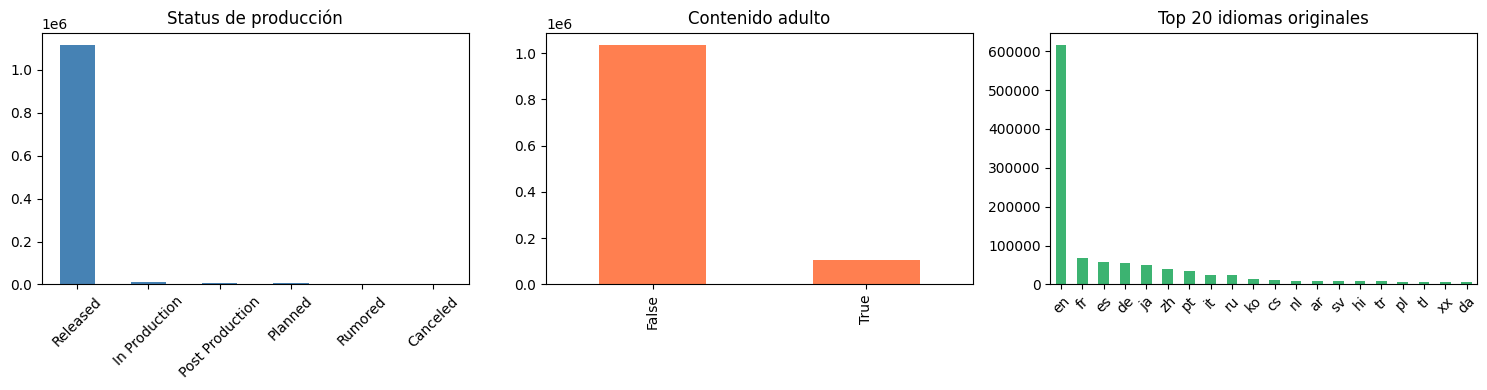

In [70]:
# ── Variables categóricas — un subplot por variable ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Status
df['status'].value_counts(dropna=False).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Status de producción')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Adult
df['adult'].value_counts(dropna=False).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Contenido adulto')
axes[1].set_xlabel('')

# Top 20 idiomas
df['original_language'].value_counts().head(20).plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Top 20 idiomas originales')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- **`status`**: ~97% de películas tiene valor `'Released'` → varianza casi nula, esta columna no aporta información discriminante → se elimina en preprocesamiento.
- **`adult`**: abrumadoramente `False` → altamente desbalanceada.
- **`original_language`**: dominado por inglés (`en`), seguido de otras lenguas europeas y asiáticas.

#### **3.4.4. Estimación de Densidad (KDE)**

El KDE muestra la forma continua de la distribución, complementando al histograma:

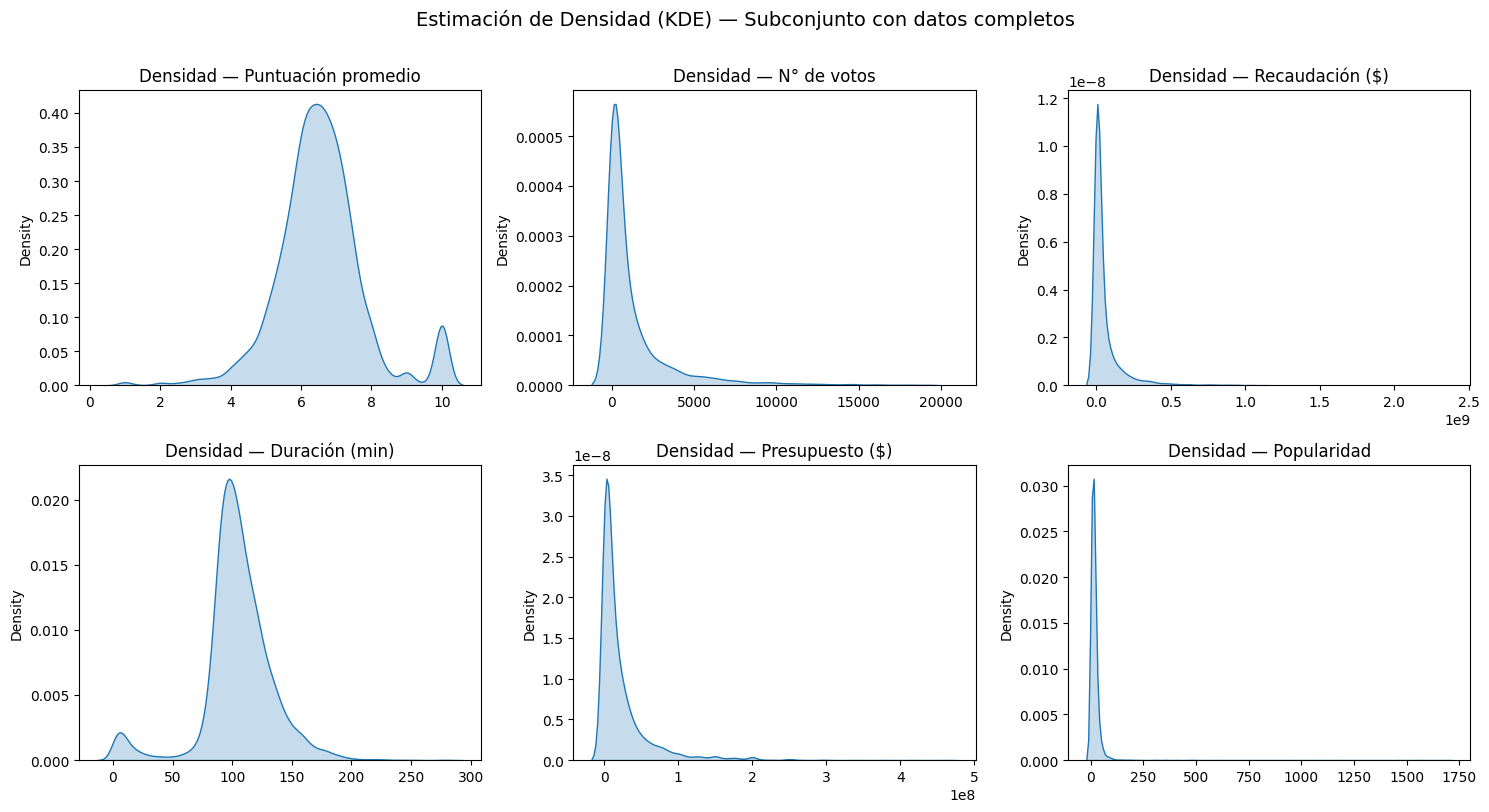

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, var, label in zip(axes, VARS_HIST, LABELS):
    sns.kdeplot(df_viz[var], fill=True, ax=ax)
    ax.set_title(f'Densidad — {label}')
    ax.set_xlabel('')

fig.suptitle('Estimación de Densidad (KDE) — Subconjunto con datos completos',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

`vote_average` y `runtime` son las variables más cercanas a una distribución normal. Las demás tienen colas largas a la derecha (*heavy-tailed*), lo que confirma que **requerirán transformación logarítmica** (`np.log1p`) antes de usarlas en modelos basados en distancia.

#### **3.4.5. Diagramas de Caja (Boxplot)**

Para comparar las variables en la misma escala, se estandarizan con `StandardScaler`:

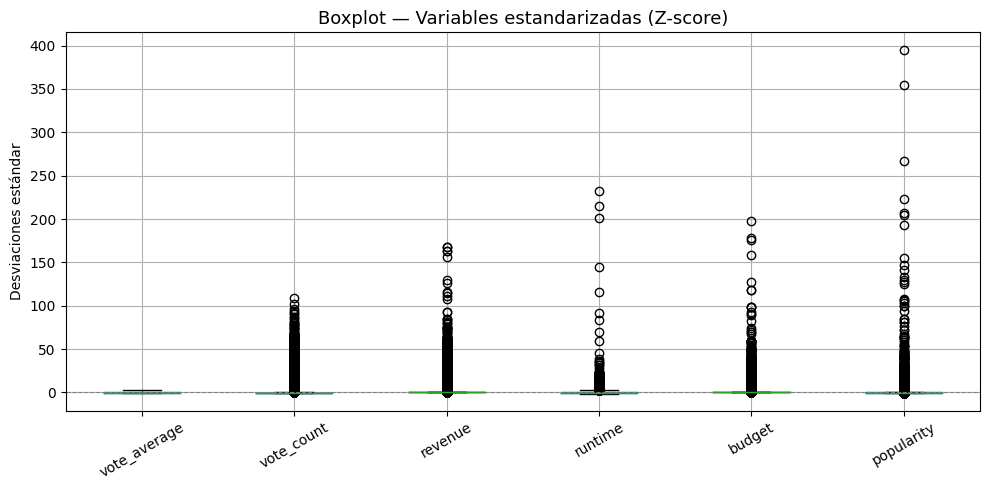

In [72]:
from sklearn.preprocessing import StandardScaler
scaler_std = StandardScaler()
df_scaled = pd.DataFrame(
    scaler_std.fit_transform(df[VARS_NUM]),
    columns=VARS_NUM
)

fig, ax = plt.subplots(figsize=(10, 5))
df_scaled.boxplot(ax=ax)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Boxplot — Variables estandarizadas (Z-score)', fontsize=13)
ax.set_ylabel('Desviaciones estándar')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Las variables financieras y `popularity` muestran outliers masivos hacia arriba. Esto no representa errores: son los blockbusters que concentran la industria. Eliminarlos sesgaría el dataset hacia producciones independientes. 

#### **3.4.6. Diagramas de Dispersión**

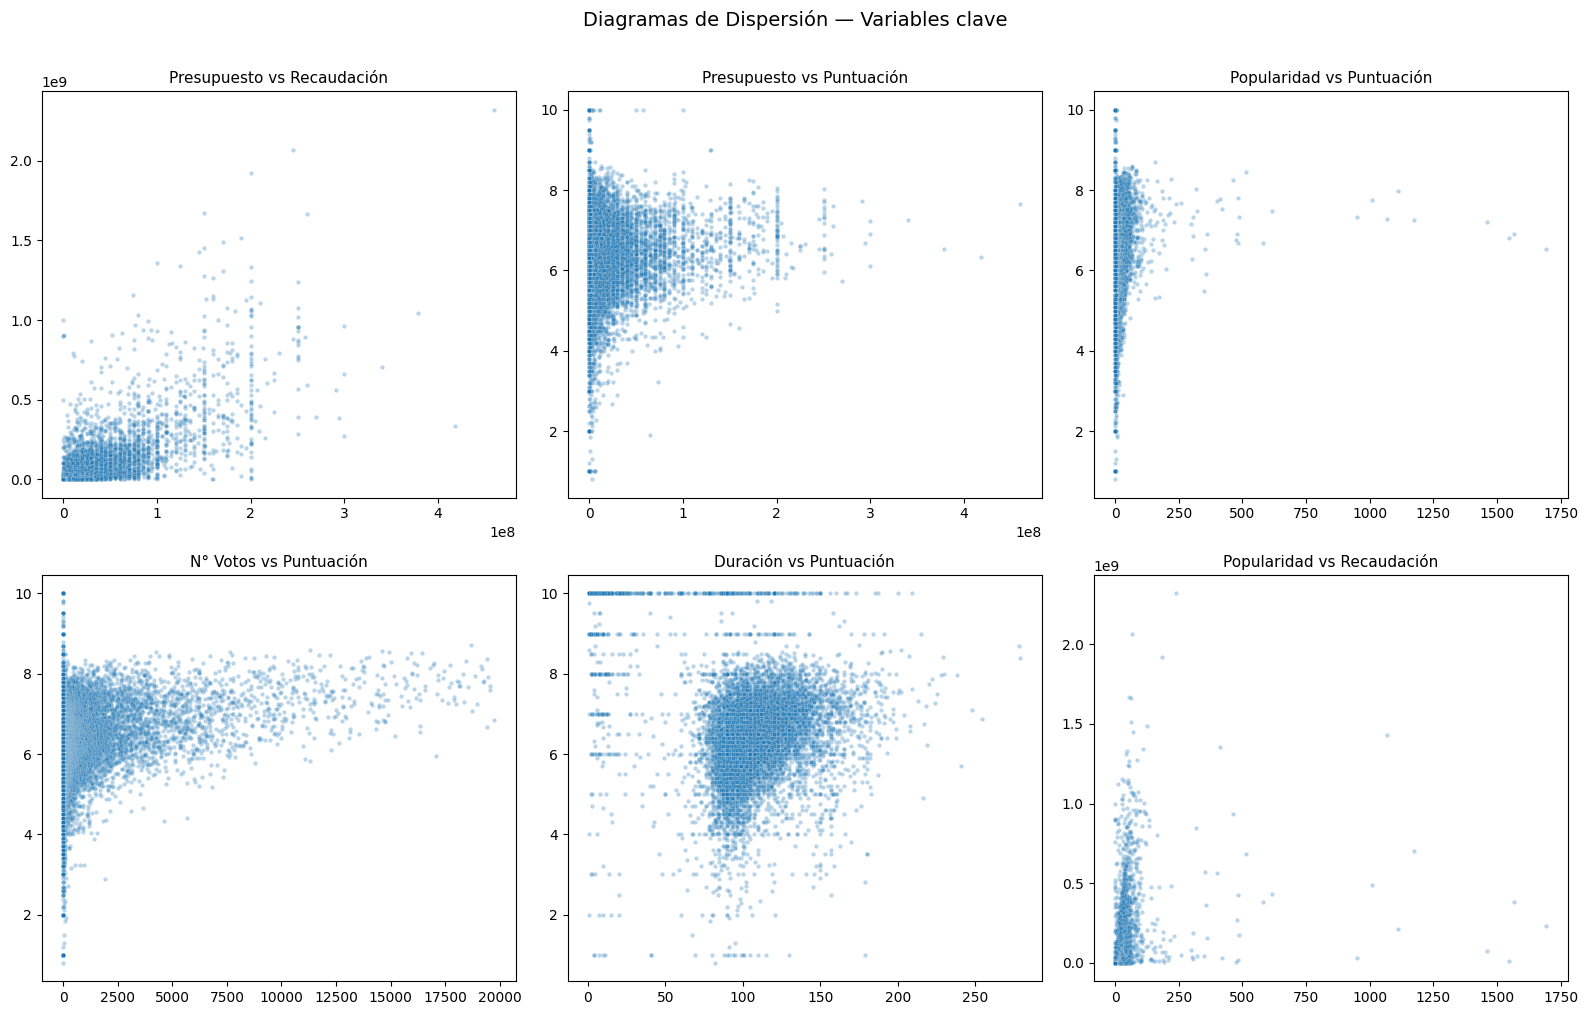

In [73]:
pares = [
    ('budget',     'revenue',      'Presupuesto vs Recaudación'),
    ('budget',     'vote_average', 'Presupuesto vs Puntuación'),
    ('popularity', 'vote_average', 'Popularidad vs Puntuación'),
    ('vote_count', 'vote_average', 'N° Votos vs Puntuación'),
    ('runtime',    'vote_average', 'Duración vs Puntuación'),
    ('popularity', 'revenue',      'Popularidad vs Recaudación'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (x, y, titulo) in zip(axes, pares):
    sns.scatterplot(data=df_viz, x=x, y=y, alpha=0.3, s=10, ax=ax)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('Diagramas de Dispersión — Variables clave', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Las relaciones observadas son consistentes con la matriz de correlación:

- **Presupuesto → Recaudación**: tendencia positiva pero con gran dispersión (el presupuesto es condición necesaria pero no suficiente para el éxito comercial).
- **Presupuesto / Popularidad → Puntuación**: sin relación clara. Las películas caras o populares no son necesariamente mejor valoradas.
- **N° Votos → Puntuación**: a más votos, la puntuación se *estabiliza* hacia la media (efecto de regresión a la media por tamaño muestral mayor).

#### **3.4.7. Radar Chart (Comparación multivariada)**

Compara el perfil numérico de 6 películas con datos completos. Todos los ejes están normalizados [0, 1] para ser comparables

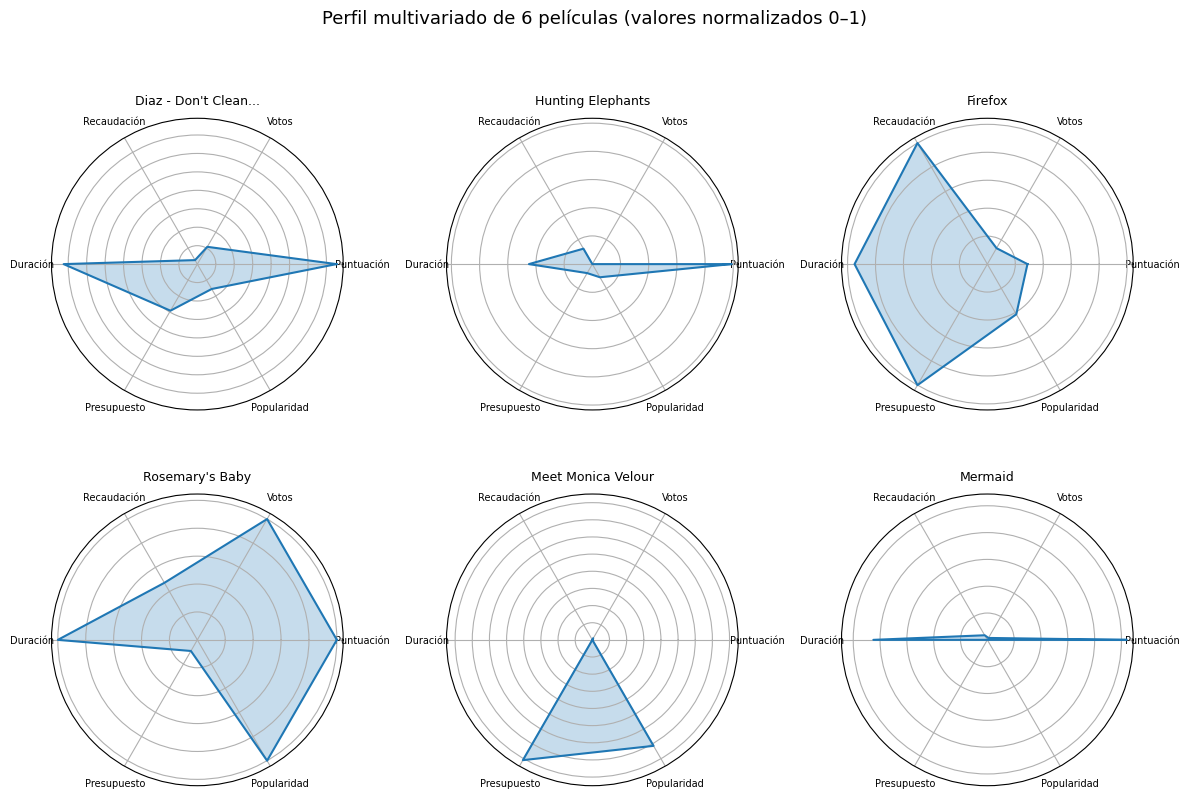

In [74]:
# ── Radar chart para 6 películas con datos completos ────────────────────
np.random.seed(42)  # reproducibilidad
sample_df = df_viz.sample(n=6)

VARS_RADAR  = ['vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity']
LABELS_RADAR = ['Puntuación', 'Votos', 'Recaudación', 'Duración', 'Presupuesto', 'Popularidad']

scaler_mm = MinMaxScaler()
scaled_values = scaler_mm.fit_transform(sample_df[VARS_RADAR])

titulos = [
    f"{t[:18]}..." if len(t) > 18 else t
    for t in sample_df['title']
]

num_vars = len(VARS_RADAR)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # cerrar el polígono

fig, axes = plt.subplots(2, 3, subplot_kw=dict(polar=True), figsize=(12, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    values = scaled_values[i].tolist() + [scaled_values[i][0]]  # cerrar
    ax.plot(angles, values, linewidth=1.5)
    ax.fill(angles, values, alpha=0.25)
    ax.set_title(titulos[i], size=9, pad=10)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(LABELS_RADAR, fontsize=7)
    ax.set_yticklabels([])

fig.suptitle('Perfil multivariado de 6 películas (valores normalizados 0–1)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**¿Cómo interpretar cada polígono?**

- **Área grande** → perfil de blockbuster (altos en múltiples dimensiones).
- **Área pequeña** → producción de nicho o independiente.
- **Forma asimétrica** → alta en una dimensión, baja en otras. Por ejemplo: una película con alta `vote_average` pero baja `popularity` es un caso de *"joya oculta"* — bien valorada por quienes la conocen, pero poco vista. Este insight es exactamente el tipo de recomendación que el sistema busca hacer.

### **3.5. Conclusiones del AED**

El análisis exploratorio revela cuatro patrones estructurales del dataset:

1. **Alta incompletitud**: las variables financieras (`budget`, `revenue`) y textuales clave (`keywords`, `genres`, `overview`) tienen entre 20% y 89% de nulos. El preprocesamiento es indispensable.

2. **Distribuciones *power-law***: `vote_count`, `popularity`, `revenue` y `budget` siguen una distribución de ley de potencia. Los outliers son fenómenos reales de la industria, no errores.

3. **Calidad ≠ éxito comercial**: `vote_average` tiene correlaciones muy bajas con todas las variables financieras. El sistema de recomendación puede explotar esta independencia para descubrir películas bien valoradas pero poco populares.

4. **Dominio del inglés**: ~75% de las películas tienen `original_language = 'en'`. Un sistema multilingüe requeriría tratamiento especial para otras lenguas.

---
## **4. Preprocesamiento de Datos**

### **4.1. Selección de Columnas**

Se trabaja sobre una copia del DataFrame original para preservar los datos fuente en memoria y garantizar trazabilidad.

In [75]:
# Preservar el dataset original
df_original = dataset['train'].to_pandas()
df = df_original.copy()

print(f'Copia creada: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Copia creada: 1,142,342 filas × 24 columnas


Columnas eliminadas y justificación:

| Columna | Razón de eliminación |
|---------|---------------------|
| `backdrop_path`, `poster_path` | Rutas de imagen — irrelevantes para recomendación textual |
| `homepage` | >89% nulos — no aporta información de contenido |
| `imdb_id` | Identificador externo — no describe similitud de contenido |
| `tagline` | >86% nulos — cobertura insuficiente para el modelo |
| `status` | ~97% valor único `'Released'` — varianza prácticamente nula |
| `original_title` | Redundante con `title` en el contexto de este recomendador |

In [76]:
COLS_ELIMINAR = [
    'backdrop_path',
    'homepage',
    'imdb_id',
    'tagline',
    'poster_path',
    'status',
    'original_title',
]

df = df.drop(columns=COLS_ELIMINAR)

print(f'Columnas restantes ({df.shape[1]}): {list(df.columns)}')

Columnas restantes (17): ['id', 'title', 'vote_average', 'vote_count', 'release_date', 'revenue', 'runtime', 'adult', 'budget', 'original_language', 'overview', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']



### **4.2. Detección y Tratamiento de Outliers**

Variables como `revenue`, `budget`, `vote_count` y `popularity` están fuertemente concentradas en valores bajos o en cero, con unos pocos outliers que elevan significativamente las medias.

Teniendo en cuenta lo anterior, primero se eliminarán estas columnas:

*   **`revenue`**: 75% de los valores en 0, no es realmente útil para el sistema de recomendación

*   **`budget`**: 75% de los valores en 0, no es realmente útil para el sistema de recomendación

En cuanto a **`popularidad`**, esta no se eliminará, ya que no es problemática, solo está sesgada (normal en consumo cultural). Sigue siendo algo parecido a una ley de potencia.

In [77]:
df = df.drop(columns=['revenue', 'budget'])

print(f'Columnas restantes ({df.shape[1]}): {list(df.columns)}')

Columnas restantes (15): ['id', 'title', 'vote_average', 'vote_count', 'release_date', 'runtime', 'adult', 'original_language', 'overview', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']


**Filtro por `vote_count >= 5`**

Películas con menos de 5 votos tienen estimaciones de `vote_average` estadísticamente inestables (alta varianza por *n* pequeño). No contribuyen a un recomendador confiable:filtro:

In [78]:
# Impacto del filtro antes de aplicarlo
total      = len(df)
con_filtro = len(df[df['vote_count'] >= 5])
print(f'Total original    : {total:>10,}')
print(f'Con ≥5 votos      : {con_filtro:>10,}')
print(f'Se descartarían   : {total - con_filtro:>10,} ({(total-con_filtro)/total*100:.1f}%)')

Total original    :  1,142,342
Con ≥5 votos      :    125,851
Se descartarían   :  1,016,491 (89.0%)


Realizamos la limpieza:

In [79]:
df = df[df['vote_count'] >= 5].copy()

print(f' Filas tras filtro vote_count>=5: {len(df):,}')

 Filas tras filtro vote_count>=5: 125,851


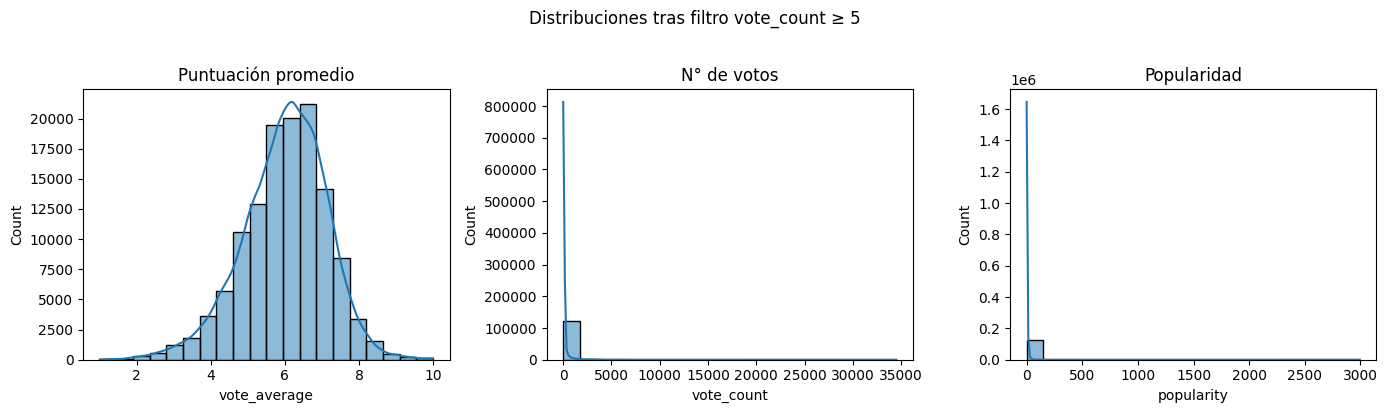

In [80]:
# Verificar efecto sobre las distribuciones
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, var, label in zip(axes,
                          ['vote_average', 'vote_count', 'popularity'],
                          ['Puntuación promedio', 'N° de votos', 'Popularidad']):
    sns.histplot(df[var], kde=True, bins=20, ax=ax)
    ax.set_title(label)

fig.suptitle('Distribuciones tras filtro vote_count ≥ 5', y=1.02)
plt.tight_layout()
plt.show()

`vote_average` ahora muestra una distribución razonable centrada entre 5 y 8. `vote_count` y `popularity` mantienen colas largas hacia la derecha — esto es esperado y correcto: sigue una distribución tipo *ley de potencia*, propia del consumo cultural.

### **4.3. Eliminación de Duplicados**

Eliminamos filas con el mismo `id` TMDB (clave primaria del dataset):

In [81]:
antes = len(df)
df = df.drop_duplicates(subset='id')
despues = len(df)

print(f'Duplicados eliminados: {antes - despues}')
print(f'Filas resultantes    : {despues:,}')

Duplicados eliminados: 0
Filas resultantes    : 125,851


### **4.4. Tratamiento de Valores Perdidos**

Verificamos el estado de nulos tras los pasos anteriores:

In [82]:
nulos_actuales = df.isnull().sum()
nulos_pct = (nulos_actuales / len(df) * 100).round(1)
resumen_nulos_actual = pd.DataFrame({
    'Nulos': nulos_actuales,
    '% del total': nulos_pct
}).query('Nulos > 0').sort_values('Nulos', ascending=False)

display(resumen_nulos_actual)

,Nulos,% del total
keywords,45958,36.5
production_companies,23484,18.7
production_countries,10234,8.1
spoken_languages,6199,4.9
genres,3930,3.1
overview,3170,2.5
release_date,120,0.1


Notamos que esta cuenta ya no es tan alta, por el proceso previo de limpieza de las celdas anteriores.

**`overview`** faltantes → 3,170 (~2.5%)

**`genres`** faltantes → 3,930 (~3%)

**`keywords`** faltantes → 45,958 (~36%)

Primero nos haremos cargo de los valores para las columnas **`overview`** y **`genres`**.

Se eliminarán las películas sin **overview** o **genres**, ya que estas variables son estructuralmente necesarias para el sistema de recomendación basado en contenido. Solamente estaríamos perdiendo ~ 4% de los datos, eso no altera la distribución general ni introduce sesgo relevante.

In [83]:
# Filas con overview nulo
no_overview = df['overview'].isnull()

# Filas con genres nulo
no_genres = df['genres'].isnull()

# Filas que tienen al menos uno nulo
to_delete = df[no_overview | no_genres]

print("Total filas:", len(df))
print("Filas a eliminar:", len(to_delete))
print("Porcentaje eliminado:", round(len(to_delete) / len(df) * 100, 2), "%")

Total filas: 125851
Filas a eliminar: 6774
Porcentaje eliminado: 5.38 %


In [84]:

mask_drop = df['overview'].isnull() | df['genres'].isnull()
print(f'Filas a eliminar (sin overview o genres): {mask_drop.sum()} '
      f'({mask_drop.sum()/len(df)*100:.1f}%)')

df = df[~mask_drop].copy()

df['keywords'] = df['keywords'].fillna('')


df['production_companies'] = df['production_companies'].fillna('Unknown')
df['production_countries'] = df['production_countries'].fillna('Unknown')


df['spoken_languages'] = df['spoken_languages'].fillna(df['original_language'])


restantes = df.isnull().sum().sum()
print(f' Nulos restantes: {restantes}')
print(f' Filas resultantes: {len(df):,}')

Filas a eliminar (sin overview o genres): 6774 (5.4%)
 Nulos restantes: 22
 Filas resultantes: 119,077


### **4.5. Tratamiento de Anomalías en Variables Continuas**

Se eliminarán las filas con valores de runtime negativos o demasiado extensos (>200 minutos), ya que esto no tiene sentido.

In [85]:
antes = len(df)
df = df[(df['runtime'] > 0) & (df['runtime'] < 200)].copy()
print(f'Filas eliminadas por runtime anómalo: {antes - len(df):,}')
print(f'Filas resultantes                   : {len(df):,}')

Filas eliminadas por runtime anómalo: 2,129
Filas resultantes                   : 116,948


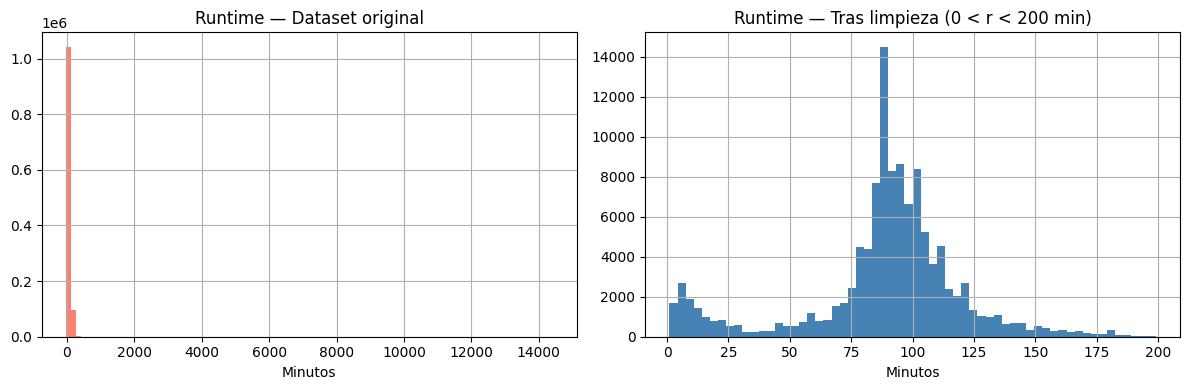

In [86]:
# Comparar distribución antes vs después
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_original['runtime'].hist(bins=100, ax=axes[0], color='salmon')
axes[0].set_title('Runtime — Dataset original')
axes[0].set_xlabel('Minutos')

df['runtime'].hist(bins=60, ax=axes[1], color='steelblue')
axes[1].set_title('Runtime — Tras limpieza (0 < r < 200 min)')
axes[1].set_xlabel('Minutos')

plt.tight_layout()
plt.show()

La distribución limpia muestra la concentración esperada entre 80 y 120 min, característica del largometraje comercial. Los valores anómalos representaban cortometrajes, errores de entrada o series catalogadas incorrectamente como películas.



---



### **4.6. Resumen del Pipeline y Feature Engineering**

In [87]:
n_original = len(df_original)
n_vcount   = len(df_original[df_original['vote_count'] >= 5])
n_final    = len(df)

pipeline = pd.DataFrame({
    'Paso': [
        '0. Dataset original',
        '1. Filtro vote_count ≥ 5',
        '2. Eliminar duplicados (id)',
        '3. Eliminar nulos en overview/genres',
        '4. Filtro runtime (0 < r < 200)',
    ],
    'Filas': [
        n_original,
        n_vcount,
        '(ver print arriba)',  # reemplazar con valor real al ejecutar
        '(ver print arriba)',
        n_final,
    ],
    'Reducción acumulada': [
        '—',
        f'{(1 - n_vcount/n_original)*100:.1f}%',
        '<0.1%',
        '~4%',
        f'{(1 - n_final/n_original)*100:.1f}% total',
    ]
})

pipeline.set_index('Paso')

,Filas,Reducción acumulada
Paso,,
0. Dataset original,1142342,—
1. Filtro vote_count ≥ 5,125851,89.0%
2. Eliminar duplicados (id),(ver print arriba),<0.1%
3. Eliminar nulos en overview/genres,(ver print arriba),~4%
4. Filtro runtime (0 < r < 200),116948,89.8% total


: 

### **4.7. Conclusión del Preprocesamiento**
 

Durante el preprocesamiento se aplicó un pipeline sistemático de 5 etapas:

1. **Selección**: se eliminaron 7 columnas irrelevantes o con >85% de nulos.
2. **Outliers**: se descartaron `budget` y `revenue` (75% de ceros) y se filtró a películas con `vote_count ≥ 5` (reduces el dataset en ~89%, eliminando registros estadísticamente no confiables).
3. **Duplicados**: sin impacto significativo (<0.1% de filas).
4. **Nulos**: tratamiento diferenciado según el rol de cada columna en el modelo (eliminación para variables estructurales, imputación simple para variables contextuales).
5. **Anomalías**: se corrigió `runtime` eliminando valores físicamente imposibles.

El resultado es un subconjunto de ~123,000 películas con alta calidad de información, listo para la etapa de construcción y entrenamiento del sistema de recomendación.